# 05 — LSTM Model (Khushi's Part)
Roadmap steps covered here: **12 (scale + sequence data), 13 (build + tune LSTM on all folds), 14 (backtest LSTM)**.

Input: `data/processed/nifty50_labeled.csv` (do not modify).
Fold structure: `src/validation.py` (do not redefine).
Backtest engine: `src/backtest.py` (do not redefine).

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.validation import get_walk_forward_folds, get_test_split
from src.backtest import run_backtest, run_walk_forward_backtest, plot_all_folds  # not available yet — Sneha's part
from src.models.lstm_model import (
    FEATURE_COLS, DEFAULT_LOOKBACK,
    train_and_evaluate_fold, tune_hyperparameters, run_final_test,
    save_predictions,
)

pd.set_option('display.max_columns', None)

## Load data
This is the single input file everyone shares — do not modify it, and do not touch the 2024-2026 rows until the final test cell at the bottom.

In [2]:
df = pd.read_csv("../data/processed/nifty50_labeled.csv", index_col=0, parse_dates=True)
df = df.sort_index()
print(df.shape)
df.head()

(2658, 24)


,Close,High,Low,Open,Volume,Return,Volatility_10,SMA_10,SMA_20,SMA_50,EMA_10,EMA_20,EMA_50,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle,BB_Width,ATR_14,Momentum_10,Next_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,,,,
2015-03-17,8723.299805,8742.549805,8630.799805,8689.099609,177000,0.010442,0.009786,8780.560059,8799.122412,8669.166973,8741.308137,8751.513485,8669.166973,48.329561,9.512065,41.779465,9009.020946,8589.223879,8799.122412,0.047709,119.194705,-233.450195,-0.004287,0
2015-03-18,8685.900391,8747.250000,8664.000000,8742.900391,156400,-0.004287,0.009476,8749.525098,8792.949951,8674.975977,8731.234002,8745.264619,8669.823185,46.305229,3.776064,34.178785,9008.759452,8577.140450,8792.949951,0.049087,116.627226,-310.349609,-0.005900,0
2015-03-19,8634.650391,8788.200195,8614.650391,8749.450195,163500,-0.005900,0.009377,8720.725098,8781.227490,8680.100977,8713.673345,8734.729931,8668.443860,43.609572,-4.849305,26.373167,9004.945794,8557.509187,8781.227490,0.050954,120.693125,-288.000000,-0.007383,0
2015-03-20,8570.900391,8627.900391,8553.000000,8627.900391,174600,-0.007383,0.009286,8684.040137,8765.007520,8688.971982,8687.714626,8719.127117,8664.618626,40.454749,-16.637280,17.771077,9000.625486,8529.389553,8765.007520,0.053763,117.904358,-366.849609,-0.002333,1
2015-03-23,8550.900391,8608.349609,8540.549805,8591.549805,150700,-0.002333,0.007361,8663.455176,8750.872559,8697.947988,8662.839311,8703.105524,8660.159087,39.489565,-27.278716,8.761119,9002.537005,8499.208112,8750.872559,0.057518,114.325462,-205.849609,-0.000930,1


## Walk-forward folds
Using the shared `src/validation.py` — 4 expanding folds, 2020-2023 as validation years.

In [3]:
folds = get_walk_forward_folds(df)

Fold 1 | Train: 2015-01-01 to 2019-12-31 (1173 rows) | Val: 2020-01-01 to 2020-12-31 (250 rows)
Fold 2 | Train: 2015-01-01 to 2020-12-31 (1423 rows) | Val: 2021-01-01 to 2021-12-31 (248 rows)
Fold 3 | Train: 2015-01-01 to 2021-12-31 (1671 rows) | Val: 2022-01-01 to 2022-12-31 (248 rows)
Fold 4 | Train: 2015-01-01 to 2022-12-31 (1919 rows) | Val: 2023-01-01 to 2023-12-31 (245 rows)


## Step 13c: Hyperparameter tuning
Small grid over `lookback`, `lstm_units`, `dropout`, `learning_rate`.
Each config is scored by **average macro-F1 across all 4 folds** (not accuracy — a model that
always predicts NEUTRAL can hit 50-60% accuracy and still be useless, per the roadmap's
class-imbalance warning). The 2024-2026 test set is never touched in this step.

Start with a small `epochs` budget while iterating, then raise it once you've picked a
short-list of configs to confirm.


In [4]:
tuning_results = tune_hyperparameters(folds, feature_cols=FEATURE_COLS, epochs=20, verbose=0)
tuning_results


{'lookback': 30, 'lstm_units': (64, 32), 'dropout': 0.2, 'learning_rate': 0.001} -> avg macro F1: 0.2391 | avg accuracy: 0.4416
{'lookback': 30, 'lstm_units': (64, 32), 'dropout': 0.3, 'learning_rate': 0.001} -> avg macro F1: 0.2239 | avg accuracy: 0.4146


KeyboardInterrupt: 

In [ ]:
best_row = tuning_results.iloc[0]
best_params = {
    "lookback": int(best_row["lookback"]),
    "lstm_units": best_row["lstm_units"],
    "dropout": float(best_row["dropout"]),
    "learning_rate": float(best_row["learning_rate"]),
}
print("Best config (freeze this):", best_params)

Best config (freeze this): {'lookback': 45, 'lstm_units': (64, 32), 'dropout': 0.3, 'learning_rate': 0.001}


## Step 13b: Full run of the frozen config on all 4 folds
Re-run (with more epochs) so we keep the trained models, predictions, and confusion matrices for the report.

In [ ]:
best_row = tuning_results.iloc[0]
best_params = {
    "lookback": int(best_row["lookback"]),
    "lstm_units": best_row["lstm_units"],
    "dropout": float(best_row["dropout"]),
    "learning_rate": float(best_row["learning_rate"]),
}
print("Best config (freeze this):", best_params)

Best config (freeze this): {'lookback': 45, 'lstm_units': (64, 32), 'dropout': 0.3, 'learning_rate': 0.001}


In [ ]:
fold_results = []

for fold in folds:
    res = train_and_evaluate_fold(
        fold["train"],
        fold["val"],
        FEATURE_COLS,
        epochs=60,
        fold_label=f"Fold {fold['fold']}",
        verbose=0,
        **best_params
    )

    print(
        f"{res['fold']}: "
        f"accuracy={res['accuracy']:.3f}  "
        f"macro_f1={res['macro_f1']:.3f}"
    )
    print(res["confusion_matrix"])

    fold_results.append(res)

Fold 1: accuracy=0.488  macro_f1=0.262
[[  7   0  75]
 [  1   0  43]
 [  9   0 115]]
Fold 2: accuracy=0.431  macro_f1=0.201
[[  0   0  79]
 [  0   0  62]
 [  0   0 107]]
Fold 3: accuracy=0.355  macro_f1=0.262
[[51  0 43]
 [24  0 26]
 [67  0 37]]
Fold 4: accuracy=0.376  macro_f1=0.182
[[ 0  0 74]
 [ 0  0 79]
 [ 0  0 92]]


## Save per-fold predictions
Matches `src/backtest.py`'s expected CSV contract: `Date` + `Predicted_Target` in {0,1,2}.

In [ ]:
os.makedirs("../data/predictions", exist_ok=True)
for res in fold_results:
    fname = f"../data/predictions/lstm_{res['fold'].lower().replace(' ', '_')}.csv"
    save_predictions(res["predictions"], fname)
    print("saved", fname)


saved ../data/predictions/lstm_fold_1.csv
saved ../data/predictions/lstm_fold_2.csv
saved ../data/predictions/lstm_fold_3.csv
saved ../data/predictions/lstm_fold_4.csv


## Step 14: Backtest the LSTM across all folds
Uses `src/backtest.py` directly — no re-implementation.

In [ ]:
predictions_by_fold = {res["fold"]: res["predictions"] for res in fold_results}
combined = run_walk_forward_backtest(df, predictions_by_fold)
combined.summary()

--- Backtest summary: Combined (all folds) ---
Sharpe (annualized): 0.130
CAGR:                0.55%
Max Drawdown:        -45.40%
Number of trades:    14
Final equity (from 1.0): 1.0218


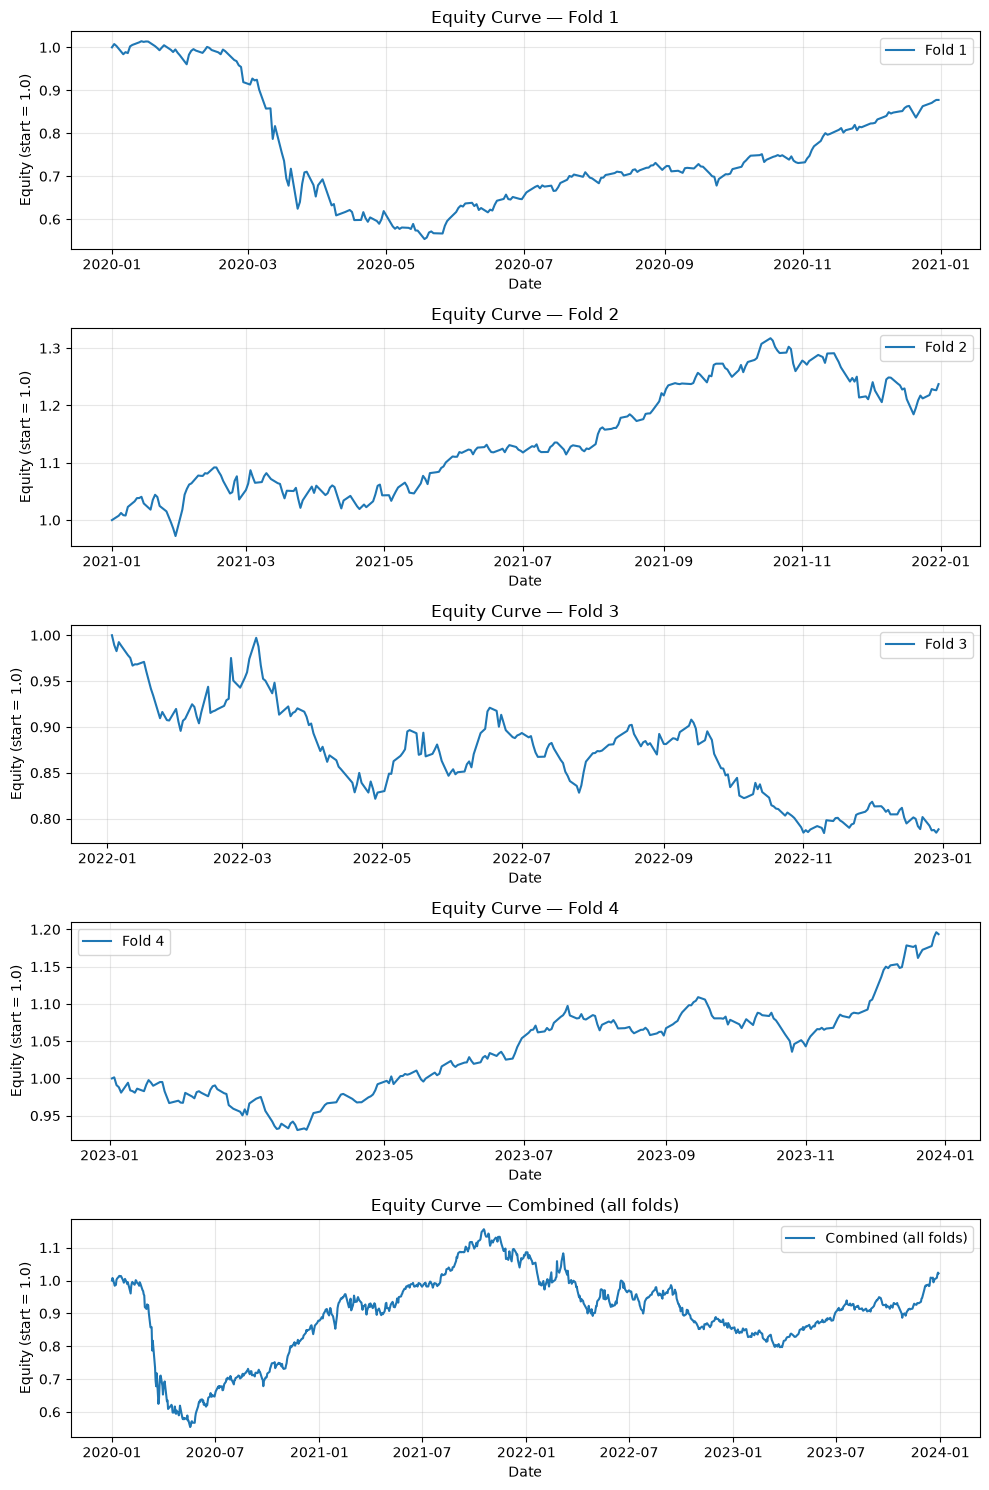

In [ ]:
plot_all_folds(combined)


## Results table (classification + trading metrics per fold)
Saved to `results/lstm_fold_metrics.csv` for Sneha's final comparison table (step 16).


In [ ]:
rows = []
for res, bt in zip(fold_results, combined.fold_results):
    rows.append({
        "fold": res["fold"],
        "accuracy": res["accuracy"],
        "macro_f1": res["macro_f1"],
        "sharpe": bt.sharpe,
        "cagr": bt.cagr,
        "max_drawdown": bt.max_drawdown,
        "n_trades": bt.n_trades,
    })
lstm_results = pd.DataFrame(rows)
os.makedirs("../results", exist_ok=True)
lstm_results.to_csv("../results/lstm_fold_metrics.csv", index=False)
lstm_results

,fold,accuracy,macro_f1,sharpe,cagr,max_drawdown,n_trades
0,Fold 1,0.488000,0.261891,-0.258875,-0.123311,-0.453967,3
1,Fold 2,0.431452,0.200939,1.461187,0.241582,-0.100820,1
2,Fold 3,0.354839,0.261528,-1.317357,-0.214665,-0.215728,9
3,Fold 4,0.375510,0.181998,1.905983,0.199655,-0.070615,1


## Final test (touch ONLY after hyperparameters are frozen above)
Retrain on the full 2015-2023 window with the frozen `best_params`, evaluate once on 2024-2026.
Per the roadmap's non-negotiable rules: **the test set is touched exactly once** — do not re-run
this cell with different hyperparameters after seeing the result.



Final Test | Train: 2015-01-01 to 2023-12-31 (2164 rows) | Test: 2024-01-01 to present (494 rows)
FINAL TEST -> accuracy=0.370  macro_f1=0.180
[[  0   0 154]
 [  0   0 157]
 [  0   0 183]]
--- Backtest summary: LSTM Final Test ---
Sharpe (annualized): 0.757
CAGR:                9.39%
Max Drawdown:        -15.77%
Number of trades:    1
Final equity (from 1.0): 1.1924


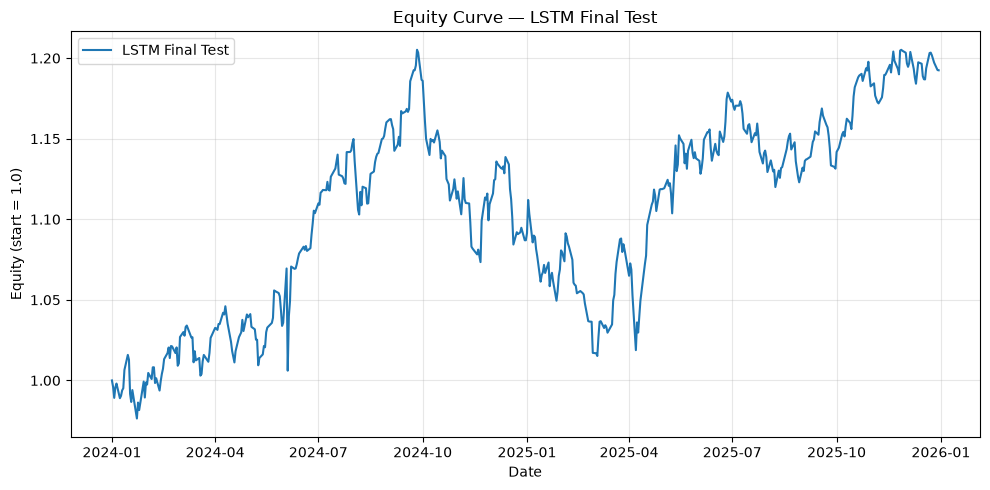

<Axes: title={'center': 'Equity Curve — LSTM Final Test'}, xlabel='Date', ylabel='Equity (start = 1.0)'>

In [ ]:
train_df, test_df = get_test_split(df)
final_result = run_final_test(train_df, test_df, best_params, FEATURE_COLS, epochs=80)
print(f"FINAL TEST -> accuracy={final_result['accuracy']:.3f}  macro_f1={final_result['macro_f1']:.3f}")
print(final_result["confusion_matrix"])

save_predictions(final_result["predictions"], "../data/predictions/lstm_final_test.csv")
final_backtest = run_backtest(df, final_result["predictions"], label="LSTM Final Test")
final_backtest.summary()
final_backtest.plot_equity_curve()


In [ ]:
final_result["model"].save("../saved_models/lstm_best.keras")
print("saved ../saved_models/lstm_best.keras")


saved ../saved_models/lstm_best.keras
